# FreshRAG Generation Stage Analysis
## How Does Staleness in Context Affect LLM Generation Efficiency?

This notebook analyzes the generation stage (Stage 4) results across four staleness conditions:
- **Fresh (0%)**: All documents are current
- **Stale-10%**: 10% of answer-bearing docs replaced with outdated versions
- **Stale-30%**: 30% replaced
- **Stale-50%**: 50% replaced

Evaluation metrics:
- **Input tokens**: Prompt token count reported by the API
- **Output tokens**: Completion token count reported by the API
- **Generation latency (ms)**: Wall-clock time per API call
- **API cost estimate (USD)**: Based on token counts and model pricing
- **Response length (words)**: Word count of the generated answer

Also examines how upstream context quality (contradiction density, redundancy, stale token ratio) correlates with generation behavior.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Style setup ──
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

COLORS = {
    'fresh': '#2ecc71',
    'stale_10': '#f1c40f',
    'stale_30': '#e67e22',
    'stale_50': '#e74c3c',
}
CONDITION_LABELS = {
    'fresh': 'Fresh (0%)',
    'stale_10': 'Stale 10%',
    'stale_30': 'Stale 30%',
    'stale_50': 'Stale 50%',
}
CONDITIONS = ['fresh', 'stale_10', 'stale_30', 'stale_50']
STALENESS_PCTS = [0, 10, 30, 50]

DOMAINS = ['covidqa', 'cuad', 'expertqa', 'finqa', 'techqa']
DOMAIN_LABELS = {
    'covidqa': 'Healthcare',
    'cuad': 'Legal',
    'expertqa': 'Expert/Cross-domain',
    'finqa': 'Finance',
    'techqa': 'SaaS/IT',
}

print('Setup complete.')

Setup complete.


In [2]:
# ── Load data ──
RESULTS_PATH = '../freshrag_experiment/results/generation_results_aggregated.json'
DETAILED_PATH = '../freshrag_experiment/results/generation_results_detailed.jsonl'

with open(RESULTS_PATH) as f:
    data = json.load(f)

detailed = []
with open(DETAILED_PATH) as f:
    for line in f:
        if line.strip():
            detailed.append(json.loads(line))

df = pd.DataFrame(detailed)

# Determine which model was used
model_name = df['model'].iloc[0] if 'model' in df.columns else 'unknown'

print(f'Sections: {list(data.keys())}')
print(f'Conditions: {list(data["overall"].keys())}')
print(f'Queries per condition: {data["overall"]["fresh"]["n"]}')
print(f'Total detailed records: {len(df)}')
print(f'Model: {model_name}')

Sections: ['overall', 'by_time_sensitivity', 'by_domain']
Conditions: ['fresh', 'stale_10', 'stale_30', 'stale_50']
Queries per condition: 289
Total detailed records: 1156
Model: gemini-2.5-flash


## 1. Overall Generation Metrics
Overview table of all metrics across staleness conditions.

In [3]:
# ── Build overview dataframe ──
overview_rows = []
for cond in CONDITIONS:
    d = data['overall'][cond]
    overview_rows.append({
        'Condition': CONDITION_LABELS[cond],
        'Staleness %': STALENESS_PCTS[CONDITIONS.index(cond)],
        'Input Tokens (mean)': d['input_tokens_mean'],
        'Output Tokens (mean)': d['output_tokens_mean'],
        'Latency ms (mean)': d['latency_ms_mean'],
        'Response Words (mean)': d['response_length_words_mean'],
        'Cost/Query USD (mean)': d['cost_usd_mean'],
        'Total Cost USD': d['cost_usd_sum'],
        'n': d['n'],
    })

df_overview = pd.DataFrame(overview_rows)
df_overview.set_index('Condition', inplace=True)
df_overview.style.format({
    'Input Tokens (mean)': '{:.1f}',
    'Output Tokens (mean)': '{:.1f}',
    'Latency ms (mean)': '{:.1f}',
    'Response Words (mean)': '{:.1f}',
    'Cost/Query USD (mean)': '{:.6f}',
    'Total Cost USD': '{:.4f}',
    'n': '{:.0f}',
}).background_gradient(cmap='RdYlGn_r', subset=['Output Tokens (mean)', 'Latency ms (mean)', 'Total Cost USD'])

,Staleness %,Input Tokens (mean),Output Tokens (mean),Latency ms (mean),Response Words (mean),Cost/Query USD (mean),Total Cost USD,n
Condition,,,,,,,,
Fresh (0%),0,3239.2,73.3,4124.2,50.6,0.000530,0.1531,289
Stale 10%,10,3232.2,78.5,4325.2,54.2,0.000532,0.1537,289
Stale 30%,30,3236.5,74.6,4363.0,51.4,0.000530,0.1532,289
Stale 50%,50,3216.5,74.6,4286.9,51.3,0.000527,0.1524,289


## 2. Token Usage & Generation Latency
How do input/output tokens and latency change with staleness?

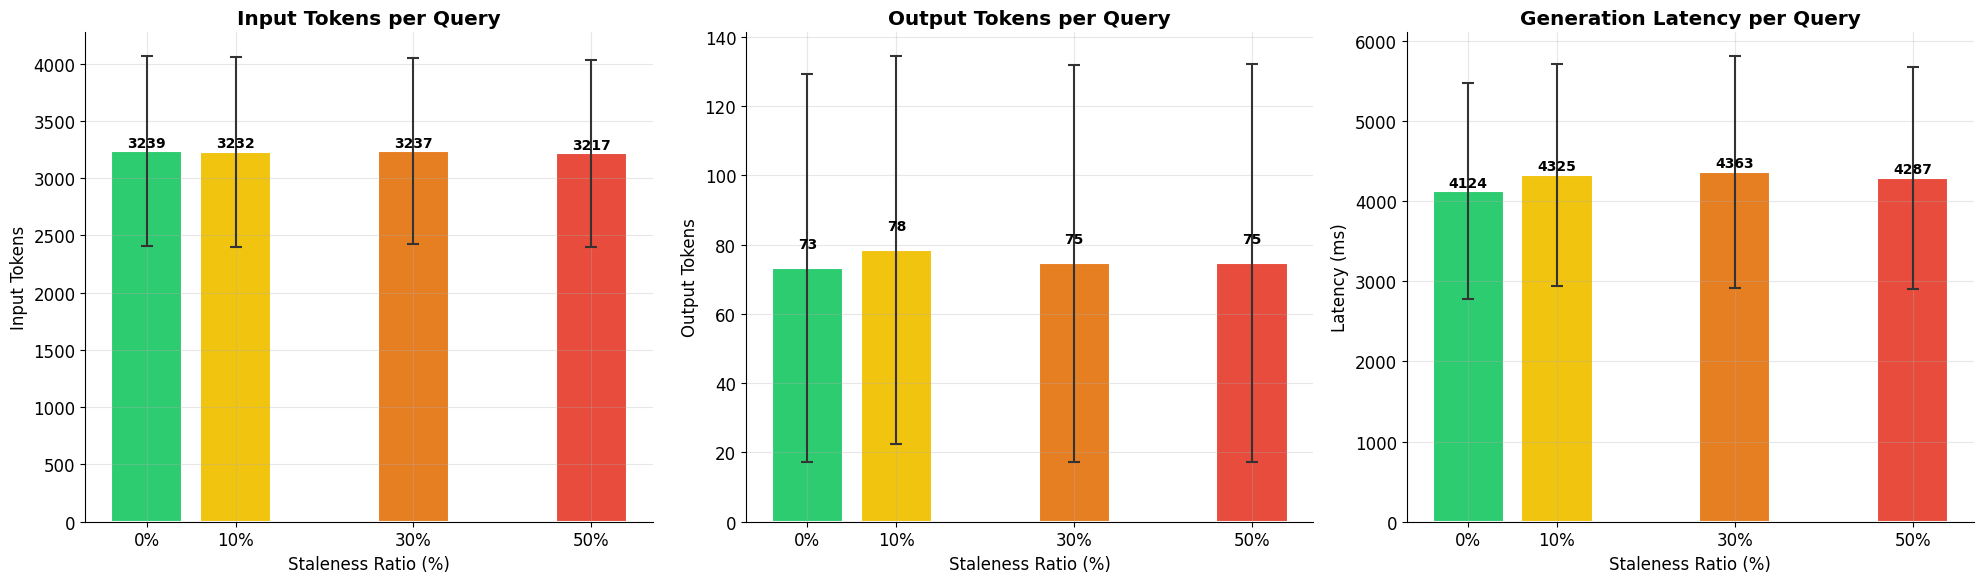

Saved: figures/fig25_generation_tokens_latency.png


In [4]:
# ── Fig 25: Input Tokens, Output Tokens, Latency ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors = [COLORS[c] for c in CONDITIONS]

# Input tokens
ax = axes[0]
vals = [data['overall'][c]['input_tokens_mean'] for c in CONDITIONS]
stds = [data['overall'][c]['input_tokens_std'] for c in CONDITIONS]
bars = ax.bar(STALENESS_PCTS, vals, width=8, color=colors, edgecolor='white', linewidth=1.5)
ax.errorbar(STALENESS_PCTS, vals, yerr=stds, fmt='none', color='#333', capsize=4, capthick=1.5)
ax.set_xlabel('Staleness Ratio (%)')
ax.set_ylabel('Input Tokens')
ax.set_title('Input Tokens per Query', fontweight='bold')
ax.set_xticks(STALENESS_PCTS)
ax.set_xticklabels(['0%', '10%', '30%', '50%'])
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 10,
            f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Output tokens
ax = axes[1]
vals = [data['overall'][c]['output_tokens_mean'] for c in CONDITIONS]
stds = [data['overall'][c]['output_tokens_std'] for c in CONDITIONS]
bars = ax.bar(STALENESS_PCTS, vals, width=8, color=colors, edgecolor='white', linewidth=1.5)
ax.errorbar(STALENESS_PCTS, vals, yerr=stds, fmt='none', color='#333', capsize=4, capthick=1.5)
ax.set_xlabel('Staleness Ratio (%)')
ax.set_ylabel('Output Tokens')
ax.set_title('Output Tokens per Query', fontweight='bold')
ax.set_xticks(STALENESS_PCTS)
ax.set_xticklabels(['0%', '10%', '30%', '50%'])
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
            f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Latency
ax = axes[2]
vals = [data['overall'][c]['latency_ms_mean'] for c in CONDITIONS]
stds = [data['overall'][c]['latency_ms_std'] for c in CONDITIONS]
bars = ax.bar(STALENESS_PCTS, vals, width=8, color=colors, edgecolor='white', linewidth=1.5)
ax.errorbar(STALENESS_PCTS, vals, yerr=stds, fmt='none', color='#333', capsize=4, capthick=1.5)
ax.set_xlabel('Staleness Ratio (%)')
ax.set_ylabel('Latency (ms)')
ax.set_title('Generation Latency per Query', fontweight='bold')
ax.set_xticks(STALENESS_PCTS)
ax.set_xticklabels(['0%', '10%', '30%', '50%'])
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 20,
            f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/fig25_generation_tokens_latency.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig25_generation_tokens_latency.png')

## 3. API Cost & Response Length
Does staleness increase generation cost and verbosity?

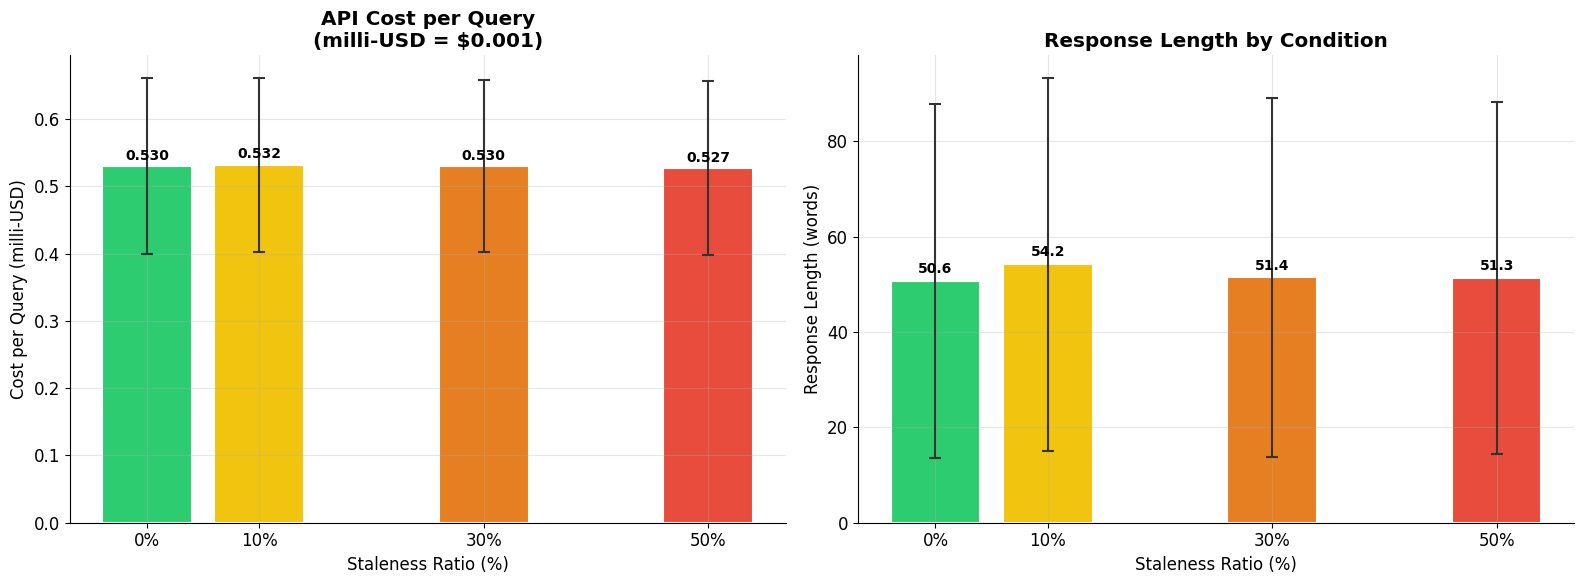

Saved: figures/fig26_generation_cost_length.png


In [5]:
# ── Fig 26: Cost & Response Length ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = [COLORS[c] for c in CONDITIONS]

# API cost per query
ax = axes[0]
vals = [data['overall'][c]['cost_usd_mean'] * 1000 for c in CONDITIONS]  # show in milli-USD
stds = [data['overall'][c]['cost_usd_std'] * 1000 for c in CONDITIONS]
bars = ax.bar(STALENESS_PCTS, vals, width=8, color=colors, edgecolor='white', linewidth=1.5)
ax.errorbar(STALENESS_PCTS, vals, yerr=stds, fmt='none', color='#333', capsize=4, capthick=1.5)
ax.set_xlabel('Staleness Ratio (%)')
ax.set_ylabel('Cost per Query (milli-USD)')
ax.set_title('API Cost per Query\n(milli-USD = $0.001)', fontweight='bold')
ax.set_xticks(STALENESS_PCTS)
ax.set_xticklabels(['0%', '10%', '30%', '50%'])
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Response length (words)
ax = axes[1]
vals = [data['overall'][c]['response_length_words_mean'] for c in CONDITIONS]
stds = [data['overall'][c]['response_length_words_std'] for c in CONDITIONS]
bars = ax.bar(STALENESS_PCTS, vals, width=8, color=colors, edgecolor='white', linewidth=1.5)
ax.errorbar(STALENESS_PCTS, vals, yerr=stds, fmt='none', color='#333', capsize=4, capthick=1.5)
ax.set_xlabel('Staleness Ratio (%)')
ax.set_ylabel('Response Length (words)')
ax.set_title('Response Length by Condition', fontweight='bold')
ax.set_xticks(STALENESS_PCTS)
ax.set_xticklabels(['0%', '10%', '30%', '50%'])
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/fig26_generation_cost_length.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig26_generation_cost_length.png')